# Автопостроение сети — Jupyter Lab

Отдельный пакет **`autoroad_planner`** (`autoroad-network-planner/`), без backend API.

Контракт JSON совпадает с BFF: терминалы с `name`, `lon`/`lat`, `coordinates`, `subtype_label`, `properties`; ответ — `terminals[]` (эхо + snap), `new_lines`, `preview`, `request_meta`. См. [README](../README.md) и `data/example_request.json`.

В приложении: **`request`** (снимок БД) → **`compute`** → **`apply`**. Здесь: **`compute_network_plan_sync(req)`** = шаг compute.

**Проверка GKS12:** *Run → Run All Cells* (или по порядку: bootstrap → расчёт → карта). Ожидаемо **~56 км**, **22 link**, **12 connector**, связность **да**.

Без Jupyter (те же артефакты в `data/`):
```powershell
cd C:\Users\user\Documents\Cursore\autoroad-network-planner
.\venv\Scripts\Activate.ps1
python notebooks\refresh_gks12_preview.py
```

**Подготовка (один раз):**
```powershell
cd C:\Users\user\Documents\Cursore\autoroad-network-planner
python -m venv venv
.\venv\Scripts\Activate.ps1
pip install -r requirements.txt
pip install -e .
pip install jupyterlab ipykernel matplotlib
python -m ipykernel install --user --name autoroad-planner --display-name "autoroad-planner"
jupyter lab
```

Kernel: **autoroad-planner**. Рабочая папка: корень `autoroad-network-planner` (родитель папки `notebooks/`).

In [1]:
import json
import sys
from pathlib import Path
from uuid import UUID, uuid4

ROOT = Path.cwd()
if not (ROOT / "autoroad_planner").is_dir():
    ROOT = Path.cwd().parent  # cwd = notebooks/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from autoroad_planner import plan_from_request, compute_network_plan_sync
from autoroad_planner.schemas import NetworkPlanRequest, PlanTerminalInput

print("package root:", ROOT.resolve())

package root: C:\Users\user\Documents\Cursore\autoroad-network-planner


In [2]:
import json
import math

from autoroad_planner.constants import TERMINAL_EXCLUSION_RADIUS_KM
from autoroad_planner.road_graph import haversine_km
from autoroad_planner.terminal_exclusion import exclusion_boundary_point


def _line_length_km(coords: list[list[float]]) -> float:
    return sum(
        haversine_km(coords[i][0], coords[i][1], coords[i + 1][0], coords[i + 1][1])
        for i in range(len(coords) - 1)
    )


def _exclusion_ring(lon: float, lat: float, *, n: int = 72) -> list[list[float]]:
    ring: list[list[float]] = []
    for i in range(n):
        bearing = 2 * math.pi * i / n
        toward_lon = lon + math.sin(bearing) * 0.05
        toward_lat = lat + math.cos(bearing) * 0.05
        blon, blat = exclusion_boundary_point(
            lon, lat, toward_lon, toward_lat, radius_km=TERMINAL_EXCLUSION_RADIUS_KM
        )
        ring.append([blon, blat])
    ring.append(ring[0])
    return ring


GKS_RAW = [
    ("6e0a2599-f391-4ca2-be46-565b71657222", "GKS_1", 37.142939119144025, 56.04061323280081),
    ("53c1e053-c2aa-4265-b972-2550efb98ef6", "GKS_2", 37.209717990505276, 56.04061323280081),
    ("3c7b0733-faa8-4f2a-bcda-c1daaf97592a", "GKS_3", 37.16123879581562, 55.94803530058053),
    ("e2357a2f-4410-4345-9429-28c76c93815c", "GKS_4", 37.22213184325423, 55.94938438681757),
    ("434f9bd5-cfca-4edd-8b5f-d73e46665cc7", "GKS_5", 37.28356554653648, 55.9487153552989),
    ("5045d9d3-df96-42bf-ac0d-ad1b3991582e", "GKS_6", 37.35034441789771, 55.9487153552989),
    ("a3c3ca43-917b-4992-a71a-4539722936ed", "GKS_7", 37.1387474374583, 56.0873732793855),
    ("24485248-e0ac-4267-b4d7-c975237cac4d", "GKS_8", 37.199455502332164, 56.08872847268688),
    ("9fd68e18-ff37-4e4b-99da-bb85a17d0718", "GKS_9", 37.34092558425556, 56.05552410800988),
    ("d0f04c1e-5cc3-436b-8f03-323a8eddb796", "GKS_10", 37.407704455616795, 56.05552410800988),
    ("3e95964b-ad96-451c-9b87-8a9a1afc3830", "GKS_11", 37.41338266237315, 55.99696486312589),
    ("5b4ea7ec-fc0b-42ef-aecf-aa4ade221282", "GKS_12", 37.47409072724702, 55.9983232116441),
]

terminals = [
    PlanTerminalInput(
        id=UUID(oid),
        subtype="gas_processing",
        subtype_label="ГКС",
        category="area_facility",
        name=name,
        lon=lon,
        lat=lat,
        coordinates=[lon, lat],
        properties={},
    )
    for oid, name, lon, lat in GKS_RAW
]

req = NetworkPlanRequest(project_id=uuid4(), terminals=terminals, existing_autoroads=[])
# Шаг compute (как POST .../autoroad-network/compute в BFF)
out = compute_network_plan_sync(req)

data_dir = ROOT / "data"
data_dir.mkdir(parents=True, exist_ok=True)
(data_dir / "gks12_request.json").write_text(req.model_dump_json(indent=2), encoding="utf-8")
(data_dir / "gks12_response.json").write_text(out.model_dump_json(indent=2), encoding="utf-8")

features = []
for t in terminals:
    features.append(
        {
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [_exclusion_ring(t.lon, t.lat)]},
            "properties": {"kind": "exclusion_zone", "name": t.name},
        }
    )
for ln in out.new_lines:
    features.append(
        {
            "type": "Feature",
            "geometry": {"type": "LineString", "coordinates": ln.coordinates},
            "properties": {"kind": ln.kind, "length_km": round(_line_length_km(ln.coordinates), 3)},
        }
    )
for nd in out.new_nodes:
    features.append(
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [nd.lon, nd.lat]},
            "properties": {"kind": "node", "reason": nd.reason},
        }
    )
for t in terminals:
    features.append(
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [t.lon, t.lat]},
            "properties": {"kind": "terminal", "name": t.name},
        }
    )
geo_path = data_dir / "gks12_from_jupyter.geojson"
geo_path.write_text(
    json.dumps({"type": "FeatureCollection", "features": features}, ensure_ascii=False),
    encoding="utf-8",
)

n_link = sum(1 for ln in out.new_lines if ln.kind == "link")
n_conn = sum(1 for ln in out.new_lines if ln.kind == "connector")
link_km = sum(_line_length_km(ln.coordinates) for ln in out.new_lines if ln.kind == "link")
conn_km = sum(_line_length_km(ln.coordinates) for ln in out.new_lines if ln.kind == "connector")
long_links = [
    (_line_length_km(ln.coordinates), ln.kind)
    for ln in out.new_lines
    if _line_length_km(ln.coordinates) > 3.0
]

connected = "terminals_not_connected" not in out.warnings
print("=== Результат плана (12 ГКС, MST + обход зон 200 m) ===")
print("Связность:", "да" if connected else "НЕТ")
print("Новая сеть, км:", round(out.total_new_km, 3), "  (ожидаемо ~50–60)")
print(f"  link: {n_link} шт., {round(link_km, 2)} км  |  connector: {n_conn} шт., {round(conn_km, 2)} км")
print("Узлы:", len(out.new_nodes))
if long_links:
    print("Длинные отрезки (>3 км):", ", ".join(f"{k:.2f} km ({kind})" for k, kind in sorted(long_links, reverse=True)))
else:
    print("Длинные отрезки (>3 км): нет (кроме рёбер MST ~3–8 км)")
warn_main = [w for w in out.warnings if w != "no_autoroad_polylines"]
if warn_main:
    print("Предупреждения:", ", ".join(warn_main[:8]), ("…" if len(warn_main) > 8 else ""))
print("Сохранено:")
print(" ", (data_dir / "gks12_response.json").resolve())
print(" ", geo_path.resolve())

=== Результат плана (12 ГКС, MST + обход зон 200 m) ===
Связность: да
Новая сеть, км: 55.787   (ожидаемо ~50–60)
  link: 22 шт., 53.39 км  |  connector: 12 шт., 2.4 км
Узлы: 23
Длинные отрезки (>3 км): 7.92 km (link), 6.25 km (link), 6.12 km (link), 4.81 km (link), 3.76 km (link), 3.75 km (link), 3.75 km (link), 3.43 km (link), 3.39 km (link), 3.38 km (link), 3.37 km (link)
Предупреждения: acute_bend_deg:134.7, acute_bend_deg:92.5, acute_bend_deg:136.5, acute_bend_deg:136.4, acute_bend_deg:136.4, acute_bend_deg:134.7, acute_bend_deg:136.6, acute_bend_deg:131.4 …
Сохранено:
  C:\Users\user\Documents\Cursore\autoroad-network-planner\data\gks12_response.json
  C:\Users\user\Documents\Cursore\autoroad-network-planner\data\gks12_from_jupyter.geojson


## Визуализация на карте (lon / lat)

Выполните ячейку **расчёта** выше, затем ячейку **ниже** — появится карта и файл `data/gks12_plan_preview.png`.

Красные кольца — **зона запрета** 200 m (`TERMINAL_EXCLUSION_RADIUS_KM = 0,2`). Зелёные квадраты — ГКС, оранжевые линии — подъезды, синие — магистраль, фиолетовые точки — узлы.

**Эталон после исправления attach (2026-06):** ~**56 км**, **22 link** + **12 connector**, дерево без длинных «перемычек» между дальними концами рёбер, **связность: да**.

PNG: C:\Users\user\Documents\Cursore\autoroad-network-planner\data\gks12_plan_preview.png


NameError: name 'Image' is not defined

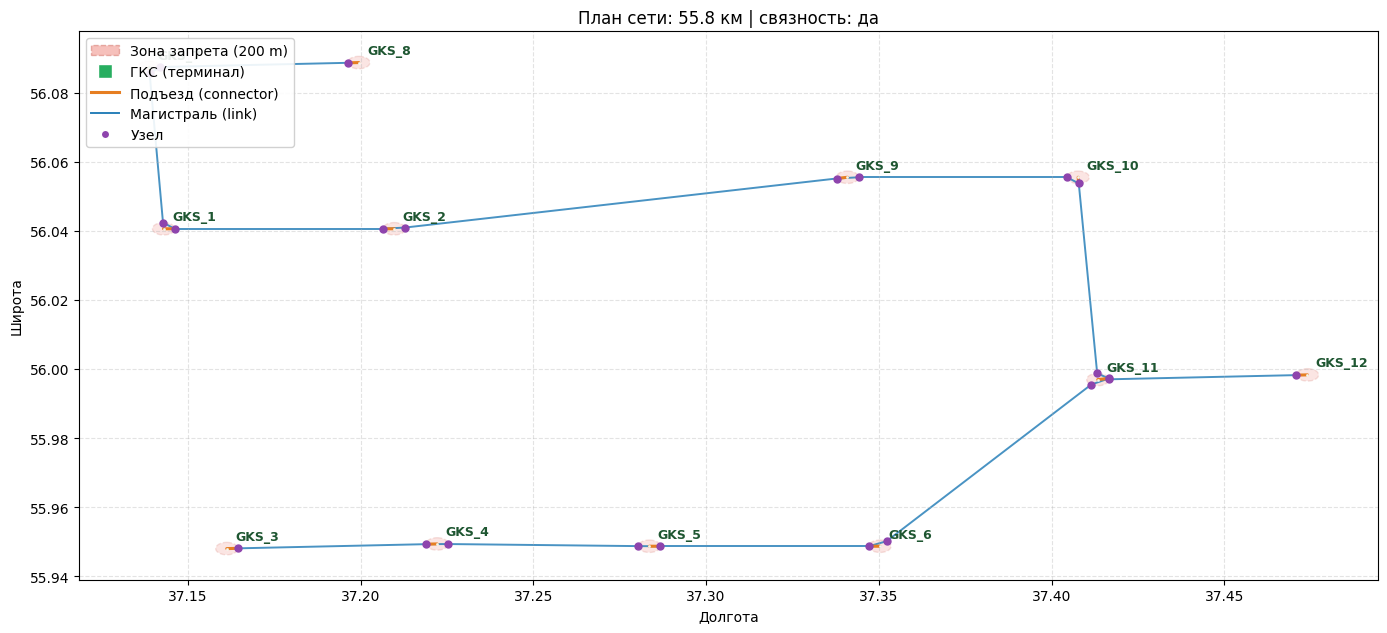

In [5]:
import math
import sys
from pathlib import Path

_ROOT = Path.cwd()
if not (_ROOT / "autoroad_planner").is_dir():
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import matplotlib.pyplot as plt
from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from autoroad_planner.constants import TERMINAL_EXCLUSION_RADIUS_KM
from autoroad_planner.schemas import NetworkPlanRequest, NetworkPlanResponse
from autoroad_planner.terminal_exclusion import exclusion_boundary_point

ROOT = _ROOT


def _ensure_plan_context() -> None:
    global req, out, terminals
    if "out" in globals() and "terminals" in globals():
        if "req" not in globals():
            req = type("_ReqFallback", (), {"existing_autoroads": []})()
        return
    resp_path = ROOT / "data" / "gks12_response.json"
    req_path = ROOT / "data" / "gks12_request.json"
    if not resp_path.is_file():
        raise RuntimeError(
            "Сначала выполните ячейку расчёта или сохраните gks12_response.json"
        )
    out = NetworkPlanResponse.model_validate_json(resp_path.read_text(encoding="utf-8"))
    if req_path.is_file():
        req = NetworkPlanRequest.model_validate_json(req_path.read_text(encoding="utf-8"))
        terminals = req.terminals
    else:
        terminals = out.terminals
        req = type("_ReqFallback", (), {"existing_autoroads": []})()
    print("загружено из JSON:", resp_path.name)


_ensure_plan_context()


def exclusion_zone_ring(lon: float, lat: float, *, radius_km: float = TERMINAL_EXCLUSION_RADIUS_KM, n: int = 72):
    ring = []
    for i in range(n):
        bearing = 2 * math.pi * i / n
        toward_lon = lon + math.sin(bearing) * 0.05
        toward_lat = lat + math.cos(bearing) * 0.05
        blon, blat = exclusion_boundary_point(lon, lat, toward_lon, toward_lat, radius_km=radius_km)
        ring.append((blon, blat))
    ring.append(ring[0])
    return ring


fig, ax = plt.subplots(figsize=(14, 10))

for t in terminals:
    ring = exclusion_zone_ring(t.lon, t.lat)
    xs = [p[0] for p in ring]
    ys = [p[1] for p in ring]
    ax.fill(
        xs,
        ys,
        color="#e74c3c",
        alpha=0.14,
        edgecolor="#c0392b",
        linewidth=1.0,
        linestyle="--",
        zorder=0,
    )

for ln in out.new_lines:
    xs = [c[0] for c in ln.coordinates]
    ys = [c[1] for c in ln.coordinates]
    if ln.kind == "connector":
        ax.plot(xs, ys, color="#e67e22", linewidth=2.2, solid_capstyle="round", zorder=2)
    else:
        ax.plot(xs, ys, color="#2980b9", linewidth=1.4, alpha=0.85, zorder=1)

for nd in out.new_nodes:
    ax.plot(nd.lon, nd.lat, "o", color="#8e44ad", markersize=5, zorder=3)

for t in terminals:
    ax.plot(t.lon, t.lat, "s", color="#27ae60", markersize=1, zorder=14, markeredgecolor="white", markeredgewidth=0.8)
    ax.annotate(
        t.name,
        (t.lon, t.lat),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
        fontweight="bold",
        color="#1e5631",
    )

ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.set_title(
    f"План сети: {out.total_new_km:.1f} км | "
    f"связность: {'да' if 'terminals_not_connected' not in out.warnings else 'нет'}"
)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.35)

legend_handles = [
    Patch(facecolor="#e74c3c", edgecolor="#c0392b", alpha=0.35, linestyle="--", label="Зона запрета (200 m)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#27ae60", markersize=10, label="ГКС (терминал)"),
    Line2D([0], [0], color="#e67e22", linewidth=2.2, label="Подъезд (connector)"),
    Line2D([0], [0], color="#2980b9", linewidth=1.4, label="Магистраль (link)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#8e44ad", markersize=6, label="Узел"),
]
ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9)

plt.tight_layout()
out_png = ROOT / "data" / "gks12_plan_preview.png"
fig.savefig(out_png, dpi=120, bbox_inches="tight")
print("PNG:", out_png.resolve())

display(Image(filename=str(out_png)))
print(
    f"Проверка: {out.total_new_km:.1f} км, "
    f"link={sum(1 for ln in out.new_lines if ln.kind == 'link')}, "
    f"связность={'да' if 'terminals_not_connected' not in out.warnings else 'нет'}"
)